# BOIL 1h candles with model confidence

In [58]:
import numpy as np
import pandas as pd

from data_loader import load_boil_data
from dataset import compute_features, create_sequences, flatten_sequences
from predictor import load_model

# Load 1h BOIL candles (keep most recent slice for clearer holdout)
raw_df = load_boil_data(period="max", interval="1d").sort_index()
raw_df = raw_df.tail(1000)

df = compute_features(raw_df)
print(f"Loaded {len(df)} candles")
df.head()

c:\Users\newco\.Zach\3rd-period-isp-cheese-trading\.venv\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Loaded 1000 candles


,Open,High,Low,Close,Volume,PctChange,IsGreen,UpperWickLength,LowerWickLength,IsLastCandle
Date,,,,,,,,,,
2022-01-28 00:00:00-05:00,4421.0,4537.0,4072.0,4204.0,53115,-4.908392,0,116.0,132.0,1
2022-01-31 00:00:00-05:00,4540.0,4791.0,4290.0,4597.0,35854,1.255507,1,194.0,250.0,1
2022-02-01 00:00:00-05:00,4381.0,4635.0,4190.0,4625.0,39713,5.569505,1,10.0,191.0,1
2022-02-02 00:00:00-05:00,5453.0,5883.0,5304.0,5602.0,58268,2.732441,1,281.0,149.0,1
2022-02-03 00:00:00-05:00,4400.0,4754.0,4326.0,4556.0,50774,3.545455,1,198.0,74.0,1


In [59]:
# Load model and compute confidence for each next candle
model = load_model("boil_model.pkl")

sequence_length = 10
X, _ = create_sequences(df, sequence_length=sequence_length)
X_flat = flatten_sequences(X)

proba = model.predict_proba(X_flat)
# Confidence = probability of IsGreen=1
confidence = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]

# Align confidence with the predicted (next) candle rows
confidence_series = pd.Series(confidence, index=df.index[sequence_length:])

df_with_conf = df.copy()
df_with_conf["Confidence"] = np.nan
df_with_conf.loc[confidence_series.index, "Confidence"] = confidence_series

# Confidence is for the same candle at that index; no shift needed
df_with_conf["SharesOwned"] = np.round((df_with_conf["Confidence"] - 0.5) * 20 * 2).shift(1)
df_with_conf["PnL"] = df_with_conf["SharesOwned"] * df_with_conf["PctChange"]

df_with_conf.tail(15)

,Open,High,Low,Close,Volume,PctChange,IsGreen,UpperWickLength,LowerWickLength,IsLastCandle,Confidence,SharesOwned,PnL
Date,,,,,,,,,,,,,
2026-01-02 00:00:00-05:00,21.830000,22.270000,21.250000,21.600000,9182000,-1.053594,0,0.440001,0.350000,1,0.361611,-6.0,6.321563
2026-01-05 00:00:00-05:00,18.670000,19.389999,18.600000,19.209999,16460000,2.892335,1,0.180000,0.070000,1,0.083227,-6.0,-17.354012
2026-01-06 00:00:00-05:00,18.570000,18.799999,18.100000,18.690001,10112700,0.646208,1,0.109999,0.469999,1,0.594635,-17.0,-10.985537
2026-01-07 00:00:00-05:00,19.370001,19.910000,19.030001,19.770000,8628400,2.065047,1,0.139999,0.340000,1,0.099044,4.0,8.260188
2026-01-08 00:00:00-05:00,18.950001,19.010000,18.020000,18.219999,13321400,-3.852250,0,0.059999,0.199999,1,0.430355,-16.0,61.636004
2026-01-09 00:00:00-05:00,16.790001,17.100000,15.720000,15.730000,23105300,-6.313290,0,0.309999,0.009999,1,0.082278,-3.0,18.939869
2026-01-12 00:00:00-05:00,16.480000,18.530001,16.330000,18.000000,15742100,9.223304,1,0.530001,0.150000,1,0.191652,-17.0,-156.796168
2026-01-13 00:00:00-05:00,17.850000,18.889999,17.610001,18.600000,11404300,4.201681,1,0.289999,0.240000,1,0.843786,-12.0,-50.420167
2026-01-14 00:00:00-05:00,16.670000,16.830000,15.690000,16.469999,21438900,-1.199765,0,0.160000,0.780000,1,0.142154,14.0,-16.796705


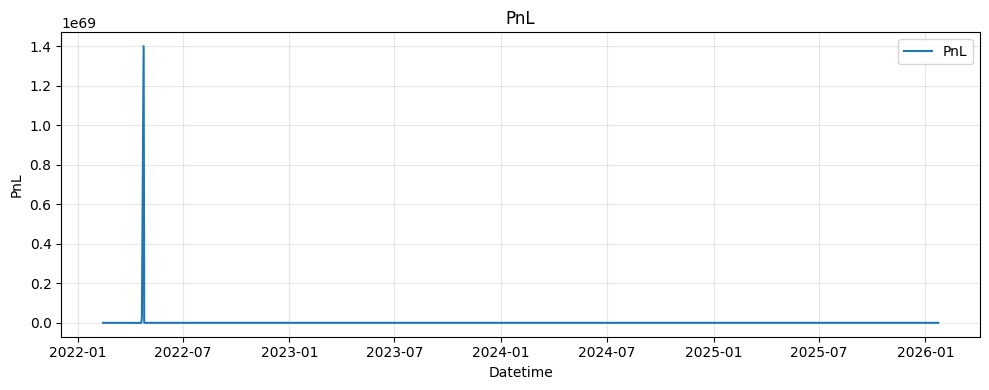

In [60]:
# Plot cumulative strategy
import matplotlib.pyplot as plt

df_with_conf["PnLCurve"] = df_with_conf["PnL"].cumprod()

plt.figure(figsize=(10, 4))
plt.plot(df_with_conf.index, df_with_conf["PnLCurve"], label="PnL")
plt.title("PnL")
plt.xlabel("Datetime")
plt.ylabel("PnL")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()